In [4]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import plot

In [5]:
# using S&P 500 stock data
Stocks=pd.read_csv("stocks.csv")
# for the model training so I can have datetime objects for time series model training
Stocks['Date'] = pd.to_datetime(Stocks['Date'])
# Sort the entire dataframe by date (oldest to newest) so I can use forward fill method
Stocks = Stocks.sort_values(by='Date')
# Index=pd.read_csv("index.csv")
# Companies=pd.read_csv("companies.csv")

In [6]:
Stocks.sample(100)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
98277,2011-03-25,AEP,NaN,NaN,NaN,NaN,NaN,NaN
34297,2011-07-14,A,NaN,NaN,NaN,NaN,NaN,NaN
23988,2015-06-29,AMD,NaN,NaN,NaN,NaN,NaN,NaN
31617,2015-11-09,AFL,NaN,NaN,NaN,NaN,NaN,NaN
75891,2012-02-10,GOOG,15.037154,15.091185,15.146477,15.043613,15.140251,93356617.0
...,...,...,...,...,...,...,...,...
59857,2023-04-06,ALGN,NaN,NaN,NaN,NaN,NaN,NaN
61750,2015-10-23,ALLE,57.692974,63.730000,64.430000,63.599998,64.379997,1077000.0
29155,2021-01-19,AES,24.773550,28.059999,28.410000,27.750000,28.049999,6587000.0
63636,2023-04-24,ALLE,100.807404,103.139999,103.709999,102.250000,103.370003,861300.0


In [7]:
len(Stocks['Symbol'].unique())
# checking how many different type of stocks we have

32

In [8]:
initial_row_count=Stocks.shape[0]
Stocks.shape

(118346, 8)

In [9]:
Stocks['Close']=Stocks.groupby('Symbol')['Close'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [10]:
Stocks.groupby('Symbol')['Close'].count()

,Close
Symbol,
A,0
ABBV,3014
ABNB,0
ABT,3768
ACN,0
ADBE,0
AEE,0
AEP,0
AES,3768


In [11]:
# drop the ones having count=0 as all of those rows having null values
counts=Stocks.groupby('Symbol')['Close'].count()
valid_close=counts[counts != 0].index.tolist()
print(valid_close)
print(len(valid_close))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [12]:
Stocks['Adj Close']=Stocks.groupby('Symbol')['Adj Close'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [13]:
counts=Stocks.groupby('Symbol')['Adj Close'].count()
valid_adj_close=counts[counts != 0].index.tolist()
print(valid_adj_close)
print(len(valid_adj_close))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [14]:
Stocks['High']=Stocks.groupby('Symbol')['High'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [15]:
counts=Stocks.groupby('Symbol')['High'].count()
valid_high=counts[counts != 0].index.tolist()
print(valid_high)
print(len(valid_high))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [16]:
Stocks['Low']=Stocks.groupby('Symbol')['Low'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [17]:
counts=Stocks.groupby('Symbol')['Low'].count()
valid_low=counts[counts != 0].index.tolist()
print(valid_low)
print(len(valid_low))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [18]:
Stocks['Open']=Stocks.groupby('Symbol')['Open'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [19]:
counts=Stocks.groupby('Symbol')['Open'].count()
valid_open=counts[counts != 0].index.tolist()
print(valid_open)
print(len(valid_open))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [20]:
Stocks['Volume']=Stocks.groupby('Symbol')['Volume'].ffill()
# after filling check which of the symbols are having null values again so simply do not consider those symbols

In [21]:
counts=Stocks.groupby('Symbol')['Volume'].count()
valid_volume=counts[counts != 0].index.tolist()
print(valid_volume)
print(len(valid_volume))

['ABBV', 'ABT', 'AES', 'ALB', 'ALL', 'ALLE', 'AMP', 'AMZN', 'AOS', 'AXP', 'GOOG', 'MO']
12


In [22]:
print(valid_adj_close==valid_close==valid_high==valid_low==valid_open==valid_volume)
# so I have found here is that some of the stocks are such that there is no data available for them in the stocks relation

True


In [23]:
Stocks=Stocks[Stocks['Symbol'].isin(valid_volume)].copy()
# only having those stocks for which we are given with data
# do not treating the stocks for which we do not have at least a single value
print(f"Total rows remaining: {len(Stocks)}")
print(f"Unique symbols left: {Stocks['Symbol'].nunique()}")

Total rows remaining: 42986
Unique symbols left: 12


In [24]:
Stocks.isnull().sum()

,0
Date,0
Symbol,0
Adj Close,1730
Close,1730
High,1730
Low,1730
Open,1730
Volume,1730


In [25]:
Stocks.groupby('Symbol').head(10)

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
75360,2010-01-04,GOOG,15.554352,15.610239,15.678981,15.547723,15.615220,78541293.0
11304,2010-01-04,ABBV,NaN,NaN,NaN,NaN,NaN,NaN
101736,2010-01-04,AXP,32.906185,40.919998,41.099998,40.389999,40.810001,6894300.0
116808,2010-01-04,AMP,28.856031,39.880001,39.970001,38.919998,39.099998,2238700.0
26376,2010-01-04,AES,9.370146,13.670000,13.700000,13.380000,13.380000,4597600.0
...,...,...,...,...,...,...,...,...
82905,2010-01-15,AMZN,6.357000,6.357000,6.482500,6.353000,6.459000,307530000.0
75369,2010-01-15,GOOG,14.394134,14.445853,14.783587,14.397036,14.778108,218194794.0
101745,2010-01-15,AXP,34.236828,42.389999,42.840000,42.020000,42.520000,13629000.0
11313,2010-01-15,ABBV,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
Stocks.dropna(subset='Close', inplace=True)
# even after removing the stocks entirely there are some stocks for which the initial rows have null values so removing those rows

In [27]:
Stocks.isnull().sum()

,0
Date,0
Symbol,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [28]:
Stocks.shape
# so now I am having only 30% data of the total data

(41256, 8)

In [29]:
Stocks.agg(['min', 'max'])

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
min,2010-01-04,ABBV,5.430500,5.430500,5.564500,5.290000,5.2965,113100.0
max,2024-12-20,MO,317.137054,325.380005,334.549988,319.230011,323.0000,848422000.0


In [30]:
# error handling like if there is a glitch
# group by with symbols to detect outliers for each stock separately
Stocks['Daily_Return']=Stocks.groupby('Symbol')['Close'].pct_change()
# columns I want to remove the outliers from
columns_to_clean=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']

# grouped iqr filtering on each column for every stock separately
for column in columns_to_clean:
    # calculate q_1 and q_3 for each column separately
    q_1=Stocks.groupby('Symbol')[column].transform(lambda x: x.quantile(0.25))
    q_3=Stocks.groupby('Symbol')[column].transform(lambda x: x.quantile(0.75))
    iqr=q_3-q_1
		# defining the limits
    lower_bound=q_1-1.5*iqr
    upper_bound=q_3+1.5*iqr

    # removing the outliers
    # keeping only the valid values
    Stocks=Stocks[(Stocks[column]>=lower_bound)&(Stocks[column]<=upper_bound)|Stocks[column].isna()]

# removing nan values from the newly created column
Stocks.dropna(subset=['Daily_Return'], inplace=True)

In [31]:
clean_rows=Stocks.shape[0]
print(Stocks.shape)
print(f"I have only {round((clean_rows/initial_row_count)*100, ndigits=2)}% rows in my final data set.")

(36277, 9)
I have only 30.65% rows in my final data set.


In [32]:
Stocks.isnull().sum()

,0
Date,0
Symbol,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0
Daily_Return,0


In [33]:
duplicates = Stocks.duplicated(subset=['Date', 'Symbol']).sum()
print(f"Duplicate rows found: {duplicates}")

Duplicate rows found: 0


### Now my data cleaning process ends here

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [35]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
})
ACCENT   = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']
BLUE     = '#58a6ff'
GREEN    = '#3fb950'
RED      = '#f78166'
PURPLE   = '#d2a8ff'
ORANGE   = '#ffa657'

In [36]:
# ── load data ─────────────────────────────────────────────────────────────────
# Paste your preprocessing code here, or load your already-cleaned dataframe.
# For this script we assume `Stocks` is ready with columns:
# Date, Symbol, Adj Close, Close, High, Low, Open, Volume, Daily_Return

# Stocks = pd.read_csv("stocks.csv")
# Stocks['Date'] = pd.to_datetime(Stocks['Date'])
# Stocks = Stocks.sort_values(by='Date')

# ── (paste your full cleaning pipeline here) ──────────────────────────────────
# Stocks['Daily_Return'] = Stocks.groupby('Symbol')['Close'].pct_change()
# columns_to_clean = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']
# for col in columns_to_clean:
#     q1 = Stocks.groupby('Symbol')[col].transform(lambda x: x.quantile(0.25))
#     q3 = Stocks.groupby('Symbol')[col].transform(lambda x: x.quantile(0.75))
#     iqr = q3 - q1
#     lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
#     Stocks = Stocks[(Stocks[col] >= lb) & (Stocks[col] <= ub) | Stocks[col].isna()]
# Stocks.dropna(subset=['Daily_Return'], inplace=True)
Stocks['Year']  = Stocks['Date'].dt.year
Stocks['Month'] = Stocks['Date'].dt.month

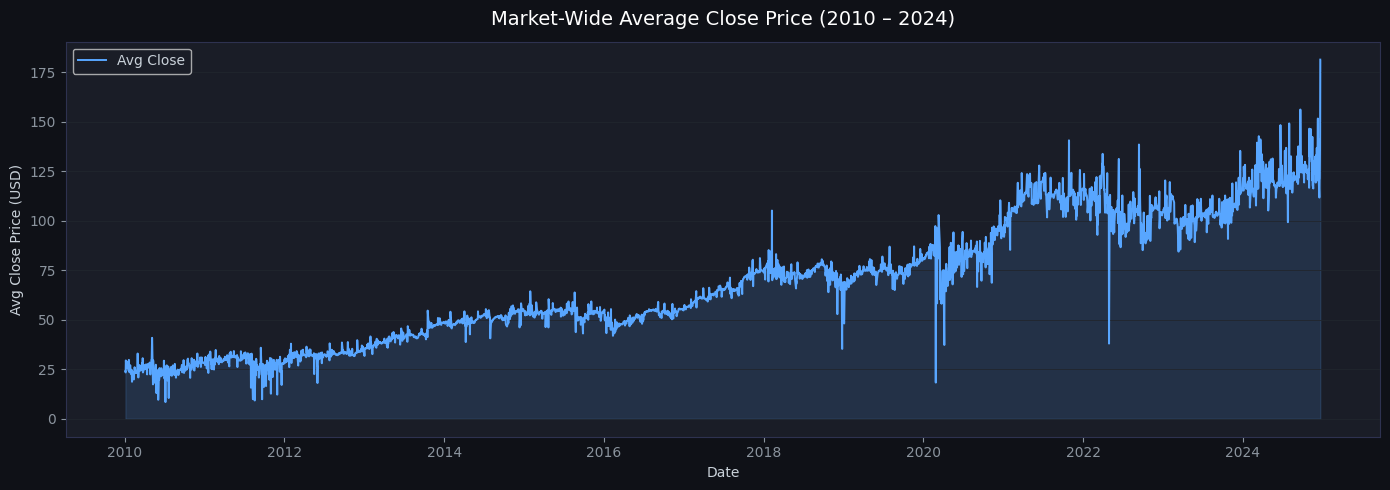

In [37]:
# PLOT 1 — Market-wide Avg Close price over time (trend)
fig, ax = plt.subplots(figsize=(14, 5))
market_trend = Stocks.groupby('Date')['Close'].mean().reset_index()
ax.plot(market_trend['Date'], market_trend['Close'], color=BLUE, lw=1.4, label='Avg Close')
ax.fill_between(market_trend['Date'], market_trend['Close'], alpha=0.15, color=BLUE)
ax.set_title('Market-Wide Average Close Price (2010 – 2024)', fontsize=14, pad=12, color='white')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Close Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, axis='y')
ax.legend()
plt.tight_layout()
plt.show()

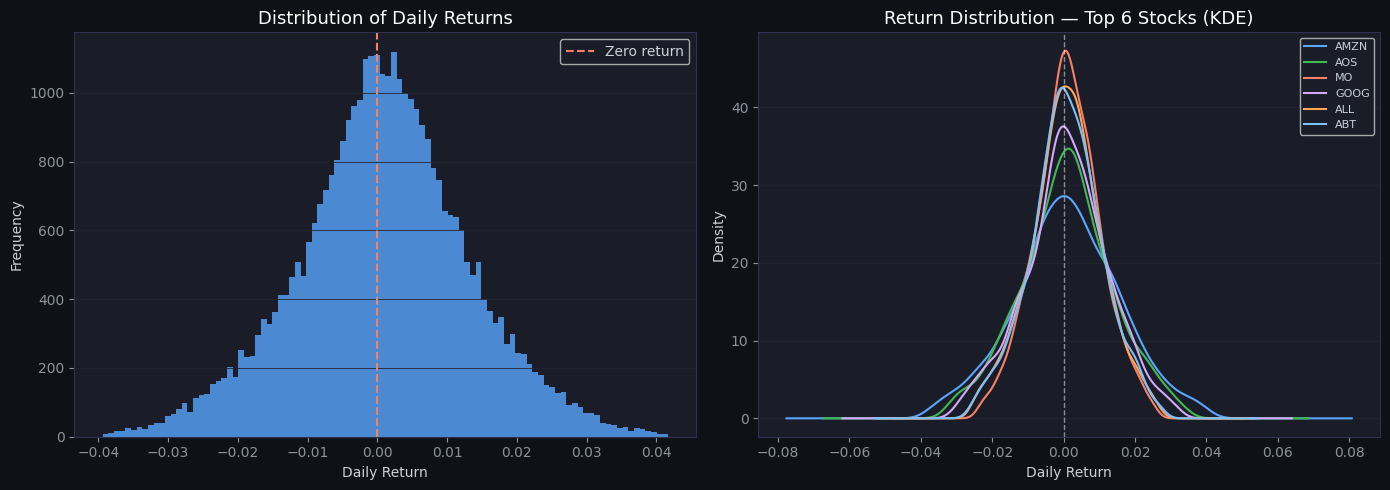

In [38]:
# PLOT 2 — Daily Return distribution (normality check)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(Stocks['Daily_Return'], bins=100, color=BLUE, alpha=0.8, edgecolor='none')
axes[0].axvline(0, color=RED, lw=1.5, linestyle='--', label='Zero return')
axes[0].set_title('Distribution of Daily Returns', fontsize=13, color='white')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, axis='y')

# KDE per sampled stock
sample_stocks = Stocks['Symbol'].value_counts().head(6).index
for i, sym in enumerate(sample_stocks):
    subset = Stocks[Stocks['Symbol'] == sym]['Daily_Return']
    subset.plot.kde(ax=axes[1], color=ACCENT[i], lw=1.5, label=sym)
axes[1].axvline(0, color='white', lw=1, linestyle='--', alpha=0.5)
axes[1].set_title('Return Distribution — Top 6 Stocks (KDE)', fontsize=13, color='white')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

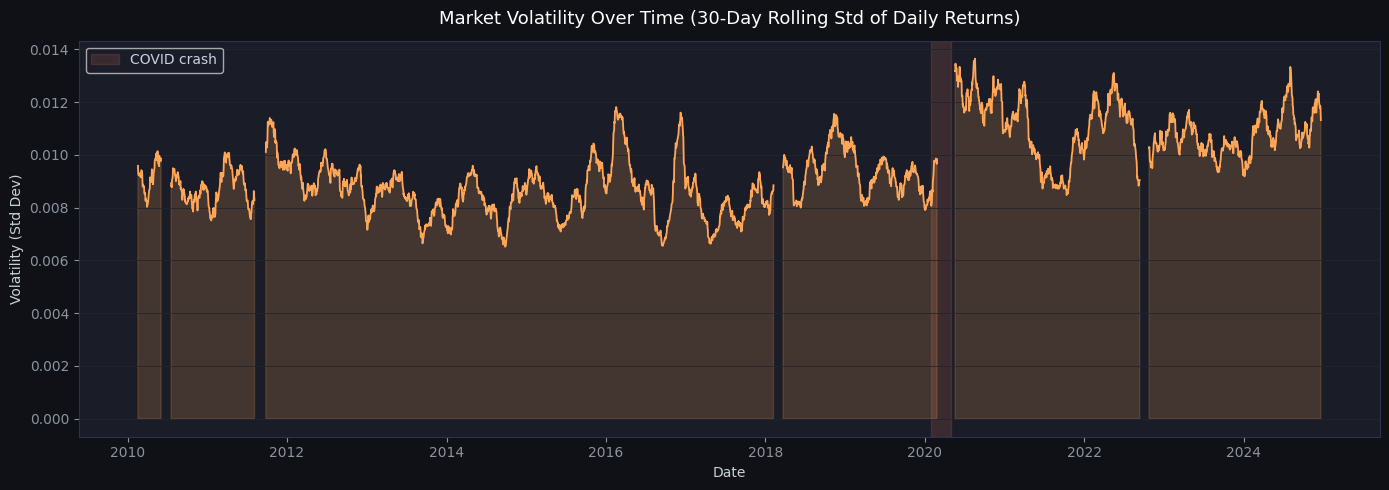

In [39]:
# PLOT 3 — Volatility over time (rolling std of daily returns)
fig, ax = plt.subplots(figsize=(14, 5))
volatility = (
    Stocks.groupby('Date')['Daily_Return']
    .std()
    .rolling(30)
    .mean()
    .reset_index()
)
volatility.columns = ['Date', 'Volatility']
ax.plot(volatility['Date'], volatility['Volatility'], color=ORANGE, lw=1.3)
ax.fill_between(volatility['Date'], volatility['Volatility'], alpha=0.18, color=ORANGE)
ax.set_title('Market Volatility Over Time (30-Day Rolling Std of Daily Returns)', fontsize=13, color='white', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std Dev)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, axis='y')
# annotate Covid crash
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           color=RED, alpha=0.15, label='COVID crash')
ax.legend()
plt.tight_layout()
plt.show()

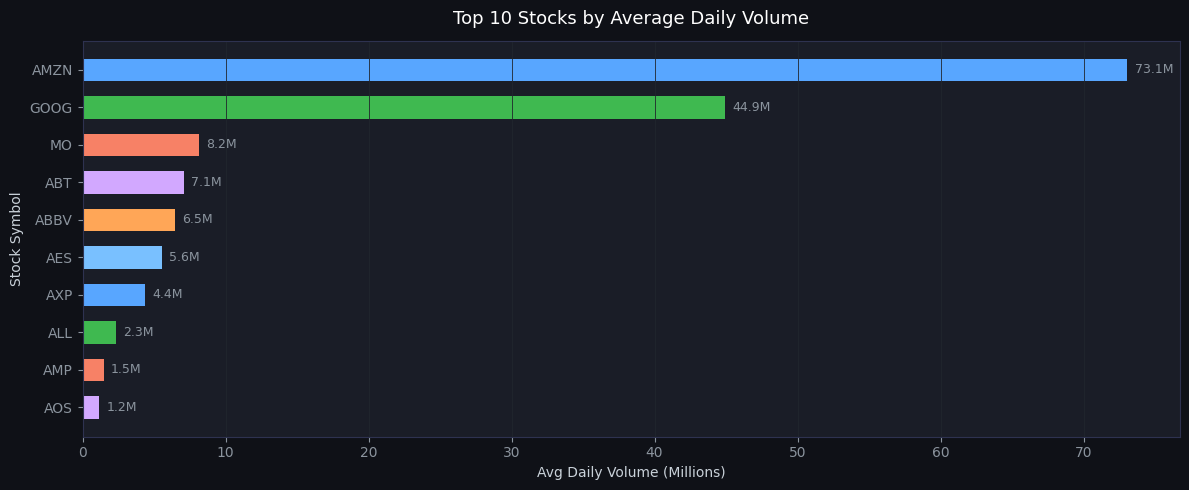

In [40]:
# PLOT 4 — Top 10 stocks by average volume
fig, ax = plt.subplots(figsize=(12, 5))
top_vol = (
    Stocks.groupby('Symbol')['Volume']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
bars = ax.barh(top_vol['Symbol'], top_vol['Volume'] / 1e6,
               color=ACCENT * 2, edgecolor='none', height=0.6)
ax.set_title('Top 10 Stocks by Average Daily Volume', fontsize=13, color='white', pad=12)
ax.set_xlabel('Avg Daily Volume (Millions)')
ax.set_ylabel('Stock Symbol')
ax.invert_yaxis()
ax.grid(True, axis='x')
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}M', va='center', fontsize=9, color='#8b949e')
plt.tight_layout()
plt.show()

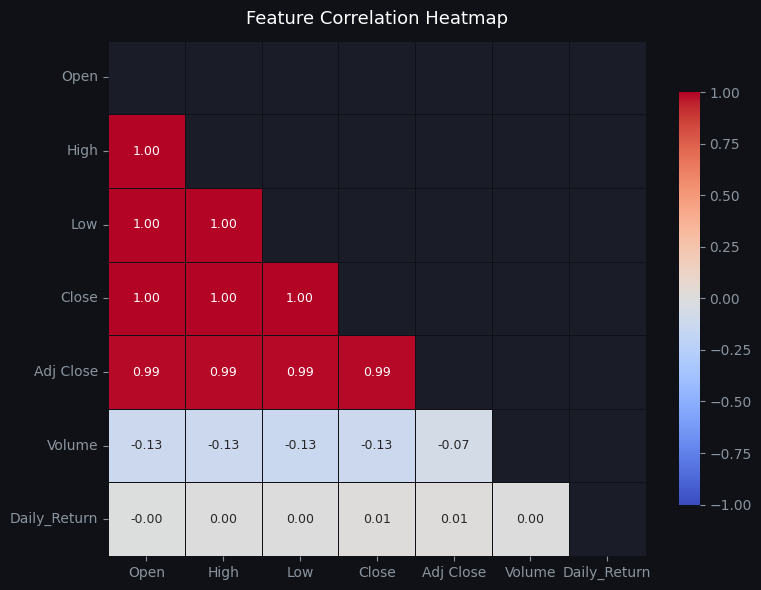

In [41]:
# PLOT 5 — Correlation heatmap of numerical features
fig, ax = plt.subplots(figsize=(8, 6))
num_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return']
corr = Stocks[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='coolwarm', vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='#0f1117',
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, color='white', pad=12)
plt.tight_layout()
plt.show()

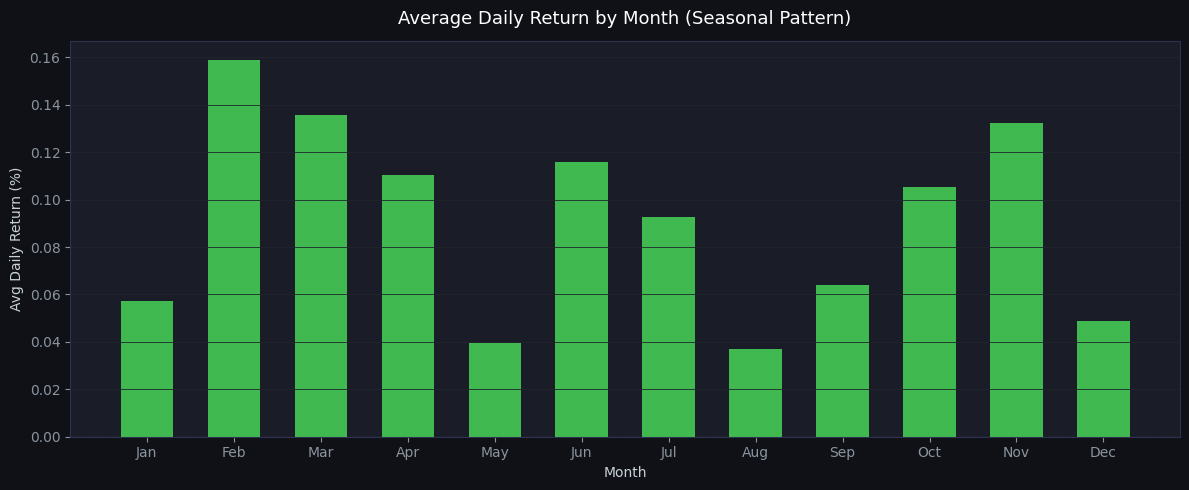

In [42]:
# PLOT 6 — Seasonal pattern: avg monthly return across all years
fig, ax = plt.subplots(figsize=(12, 5))
monthly_avg = (
    Stocks.groupby('Month')['Daily_Return']
    .mean() * 100
)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = [GREEN if v >= 0 else RED for v in monthly_avg]
ax.bar(month_names, monthly_avg, color=colors, edgecolor='none', width=0.6)
ax.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('Average Daily Return by Month (Seasonal Pattern)', fontsize=13, color='white', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Avg Daily Return (%)')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

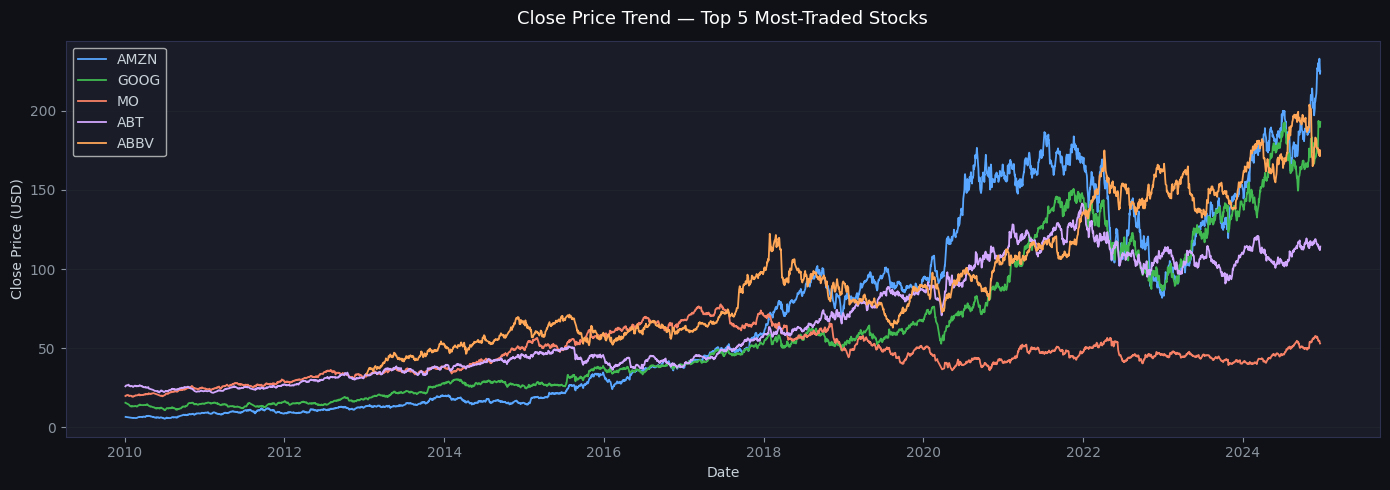

In [43]:
# PLOT 7 — Price trend for top 5 most-traded stocks
fig, ax = plt.subplots(figsize=(14, 5))
top5 = Stocks.groupby('Symbol')['Volume'].mean().sort_values(ascending=False).head(5).index
for i, sym in enumerate(top5):
    s = Stocks[Stocks['Symbol'] == sym].set_index('Date')['Close']
    ax.plot(s.index, s.values, color=ACCENT[i], lw=1.3, label=sym)
ax.set_title('Close Price Trend — Top 5 Most-Traded Stocks', fontsize=13, color='white', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

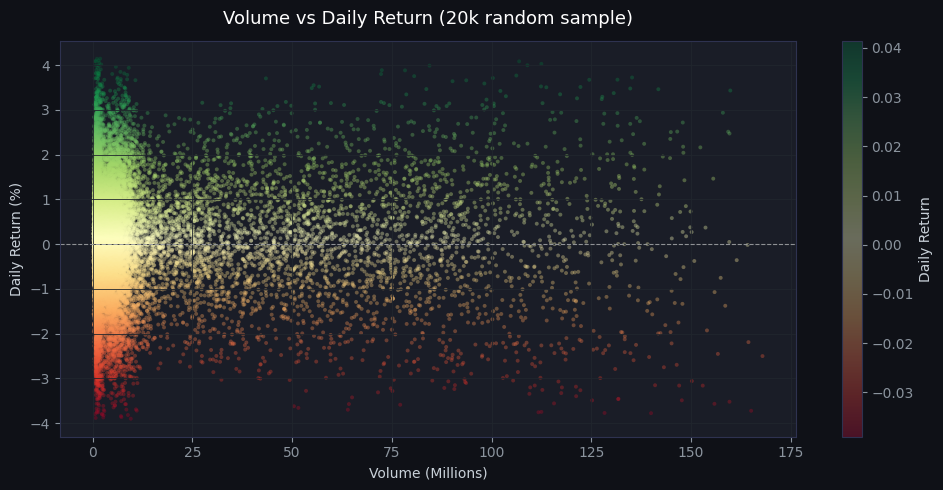

In [44]:
# PLOT 8 — Volume vs Daily Return scatter (market-wide sample)
fig, ax = plt.subplots(figsize=(10, 5))
sample = Stocks.sample(min(20000, len(Stocks)), random_state=42)
sc = ax.scatter(
    sample['Volume'] / 1e6,
    sample['Daily_Return'] * 100,
    c=sample['Daily_Return'],
    cmap='RdYlGn', alpha=0.35, s=8, linewidths=0
)
plt.colorbar(sc, ax=ax, label='Daily Return')
ax.axhline(0, color='white', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title('Volume vs Daily Return (20k random sample)', fontsize=13, color='white', pad=12)
ax.set_xlabel('Volume (Millions)')
ax.set_ylabel('Daily Return (%)')
ax.grid(True)
plt.tight_layout()
plt.show()

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
#  MODEL 2 — LSTM (Main Model)
#  Target  : Next day's Close price
#  Approach: Per-symbol sliding window sequences fed into an LSTM network
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

# ── 0. Paste / run your full preprocessing pipeline here ─────────────────────
#    At the end you should have clean `Stocks` with:
#    Date, Symbol, Open, High, Low, Close, Adj Close, Volume, Daily_Return

# Stocks = <your cleaned dataframe>

# ── 1. Config ────────────────────────────────────────────────────────────────
WINDOW      = 30        # look-back window (days)
FEATURES    = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']
TARGET_COL  = 'Close'
SPLIT_DATE  = '2023-01-01'
BATCH_SIZE  = 256
EPOCHS      = 50
MIN_ROWS    = 150       # skip symbols with too little data after split

# ── 2. Build sequences for one symbol ────────────────────────────────────────
def make_sequences(df_sym, scaler, window, fit_scaler=True):
    """
    Returns X (N, window, features) and y (N,) arrays.
    scaler is fit on train data only and reused for test.
    """
    vals = df_sym[FEATURES].values
    if fit_scaler:
        vals = scaler.fit_transform(vals)
    else:
        vals = scaler.transform(vals)

    X, y = [], []
    close_idx = FEATURES.index(TARGET_COL)
    raw_close = df_sym[TARGET_COL].values   # unscaled — for inverse-transform later

    for i in range(window, len(vals)):
        X.append(vals[i - window : i])
        y.append(raw_close[i])              # target stays unscaled

    return np.array(X), np.array(y)

# ── 3. Prepare train / test arrays across all symbols ────────────────────────
print("Building sequences across all symbols (this may take ~1 min)...")

X_train_all, y_train_all = [], []
X_test_all,  y_test_all  = [], []
scalers = {}   # one scaler per symbol (fit on train only)

Stocks_sorted = Stocks.sort_values(['Symbol', 'Date'])

for sym, grp in Stocks_sorted.groupby('Symbol'):
    grp = grp.reset_index(drop=True)

    train_df = grp[grp['Date'] <  SPLIT_DATE]
    test_df  = grp[grp['Date'] >= SPLIT_DATE]

    if len(train_df) < MIN_ROWS or len(test_df) < 30:
        continue

    sc = MinMaxScaler()
    scalers[sym] = sc

    X_tr, y_tr = make_sequences(train_df, sc, WINDOW, fit_scaler=True)
    X_te, y_te = make_sequences(test_df,  sc, WINDOW, fit_scaler=False)

    if len(X_tr) == 0 or len(X_te) == 0:
        continue

    X_train_all.append(X_tr);  y_train_all.append(y_tr)
    X_test_all.append(X_te);   y_test_all.append(y_te)

X_train = np.concatenate(X_train_all, axis=0)
y_train = np.concatenate(y_train_all, axis=0)
X_test  = np.concatenate(X_test_all,  axis=0)
y_test  = np.concatenate(y_test_all,  axis=0)

print(f"Train sequences : {X_train.shape}")
print(f"Test  sequences : {X_test.shape}")

# ── 4. Build LSTM model ───────────────────────────────────────────────────────
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(1)        # regression output — predicts Close price
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_lstm((WINDOW, len(FEATURES)))
model.summary()

# ── 5. Callbacks ─────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
]

# ── 6. Train ─────────────────────────────────────────────────────────────────
print("\nTraining LSTM...")
history = model.fit(
    X_train, y_train,
    validation_split = 0.1,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = callbacks,
    verbose          = 1,
)

# ── 7. Evaluate ───────────────────────────────────────────────────────────────
y_pred = model.predict(X_test).flatten()

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("\n══════════════════════════════")
print("  LSTM — Test Metrics")
print("══════════════════════════════")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print("══════════════════════════════\n")

# ── 8. Training loss curve ────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='#58a6ff')
plt.plot(history.history['val_loss'], label='Val Loss',   color='#f78166')
plt.title('LSTM — Training vs Validation Loss', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9. Predicted vs Actual (on test portion of a single stock) ───────────────
# Pick a stock that had enough test sequences
EXAMPLE_SYM = list(scalers.keys())[5]

grp_ex      = Stocks_sorted[Stocks_sorted['Symbol'] == EXAMPLE_SYM]
test_ex_df  = grp_ex[grp_ex['Date'] >= SPLIT_DATE].reset_index(drop=True)
sc_ex       = scalers[EXAMPLE_SYM]

X_ex, y_ex = make_sequences(test_ex_df, sc_ex, WINDOW, fit_scaler=False)
y_ex_pred   = model.predict(X_ex).flatten()
dates_ex    = test_ex_df['Date'].iloc[WINDOW:].values

plt.figure(figsize=(13, 4))
plt.plot(dates_ex, y_ex,      label='Actual',    color='#3fb950', lw=1.4)
plt.plot(dates_ex, y_ex_pred, label='Predicted', color='#f78166', lw=1.4, alpha=0.85)
plt.title(f'LSTM — Actual vs Predicted Close | {EXAMPLE_SYM}', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 10. Save model ───────────────────────────────────────────────────────────
model.save('lstm_stock_model.keras')
print("✅  LSTM done. Model saved as lstm_stock_model.keras")

Building sequences across all symbols (this may take ~1 min)...
Train sequences : (30022, 30, 6)
Test  sequences : (4175, 30, 6)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,409 (474.25 KB)

 Trainable params: 121,025 (472.75 KB)

 Non-trainable params: 384 (1.50 KB)


Training LSTM...
Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 36s 293ms/step - loss: 3519.4797 - mae: 50.0017 - val_loss: 590.0641 - val_mae: 21.5816 - learning_rate: 0.0010
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 276ms/step - loss: 1034.5508 - mae: 26.0155 - val_loss: 195.0672 - val_mae: 11.0220 - learning_rate: 0.0010
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - loss: 668.9097 - mae: 19.9844 - val_loss: 288.5084 - val_mae: 14.8904 - learning_rate: 0.0010
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - loss: 644.6218 - mae: 19.5511 - val_loss: 518.1782 - val_mae: 19.0529 - learning_rate: 0.0010
Epoch 5/50


KeyboardInterrupt: 